# AP_plots
AFM force-curve analysis pipeline for Asylum Research `.ibw` files.

**Workflow:**
1. Load config & resolve per-run data paths from the `experiment` field
2. Load a single curve and inspect the DataFrame
3. Plot approach vs. retract for a single file
4. Average key indices across sweeps for each force setpoint
5. Build a results DataFrame and plot ΔDefl vs. ΔZ
6. Fit Force vs. ΔDefl to extract the spring constant *k*

## Imports

In [232]:
import glob
import os
import re

import igor2.binarywave as bw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import linregress
import plotly.graph_objects as go

## Step 1 – Load config & resolve paths

`AP_runs.yaml` lives in the master folder. Each run entry has an `experiment` field (e.g. `AP_1`) that points to its subfolder. Raw `.ibw` files are read directly from `<master>/<experiment>/raw/`.

In [233]:
# Master folder that contains AP_runs.yaml and all AP_* experiment subfolders
MASTER_DIR = '/Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/'
YAML_FILE  = os.path.join(MASTER_DIR, 'AP_runs.yaml')

with open(YAML_FILE, 'r') as f:
    config = yaml.safe_load(f)

def raw_dir(run):
    """Return the raw/ directory for a given run, derived from its 'experiment' field."""
    experiment = config[run]['experiment']   # e.g. 'AP_1'
    return os.path.join(MASTER_DIR, experiment, 'raw')

# Quick sanity check
for run in config:
    print(f'{run}  →  {raw_dir(run)}')

run_FD  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_1/raw
run_FD2  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_1/raw
run_FD3  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_2/raw
run_FD4  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_3/raw
run_FD5  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_3/raw
run_FD6  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_3/raw
run_FD7  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_3/raw


## Helper functions

In [185]:
def load_ibw(filepath):
    """Return (DataFrame, metadata-dict) for an Asylum .ibw file."""
    data   = bw.load(filepath)
    wave   = data['wave']
    labels = [l.decode() for l in wave['labels'][1] if l]
    df     = pd.DataFrame(wave['wData'], columns=labels)

    meta = {}
    for line in wave['note'].decode('latin-1').split('\r'):
        if ':' in line:
            key, _, val = line.partition(':')
            meta[key.strip()] = val.strip()

    return df, meta


def parse_force_to_N(force_str):
    """
    Convert a force string to Newtons.
    Accepts 'p' as a decimal separator (e.g. '1p2uN' -> 1.2e-6 N)
    and plain integer values (e.g. '10uN', '500nN').
    """
    normalised = force_str.replace('p', '.')
    val, unit  = re.match(r'([\d.]+)(nN|uN)', normalised).groups()
    return float(val) * (1e-9 if unit == 'nN' else 1e-6)

def get_curve_indices(filepath, defl_threshold_nm=2, window=50):
    df, _ = load_ibw(filepath)

    defl = df['Defl'].to_numpy() * 1e9  # → nm

    # Right edge: global maximum
    idx_max = int(np.argmax(defl))

    # Rolling mean of deflection (only up to idx_max)
    defl_series  = pd.Series(defl[:idx_max])
    rolling_mean = defl_series.rolling(window=window, min_periods=1).mean().to_numpy()

    # Left edge: first point where deflection rises more than threshold above local rolling mean
    diff = defl[:idx_max] - rolling_mean
    spike_start = np.where(diff > defl_threshold_nm)[0]
    idx_min = int(spike_start[0]) if len(spike_start) > 0 else 0

    return [idx_min], [idx_max]

def get_average_indices(run, acquisition):
    """
    Average DeltaDefl and DeltaZ across all sweeps for a given run/force setpoint.
    Returns a dict {'delta_defl': float, 'delta_z': float}, or None if no files found.
    """
    data_dir = raw_dir(run)
    pattern  = os.path.join(glob.escape(data_dir), f'{run}_{acquisition}_*.ibw')
    files    = glob.glob(pattern)

    if not files:
        print(f'  [warn] No files found for {run}  {acquisition}')
        return None

    all_start_defl, all_lg_defl = [], []
    all_start_z,    all_lg_z    = [], []

    for fp in files:
        df, _          = load_ibw(fp)
        [idx_min], [idx_max] = get_curve_indices(fp)

        all_start_defl.append(df['Defl'].iloc[idx_min])
        all_lg_defl.append(df['Defl'].iloc[idx_max])

        all_start_z.append(df['ZSnsr'].iloc[idx_min])
        all_lg_z.append(df['ZSnsr'].iloc[idx_max])

    return {
        'delta_defl': np.mean(all_lg_defl) - np.mean(all_start_defl),
        'delta_z':    np.mean(all_lg_z)    - np.mean(all_start_z),
    }

## Step 2 – Inspect a single file

In [186]:
EXAMPLE_RUN  = 'run_FD5'
EXAMPLE_FILE = 'run_FD5_100uN_0008.ibw'
example_path = os.path.join(raw_dir(EXAMPLE_RUN), EXAMPLE_FILE)

df_example, meta_example = load_ibw(example_path)
df_example.head()

,Raw,Defl,ZSnsr
0,0.000005,-4.188728e-07,0.000005
1,0.000005,-4.188616e-07,0.000005
2,0.000005,-4.188529e-07,0.000005
3,0.000005,-4.188918e-07,0.000005
4,0.000005,-4.189325e-07,0.000005


## Step 3 – Plot approach vs. retract for the example file

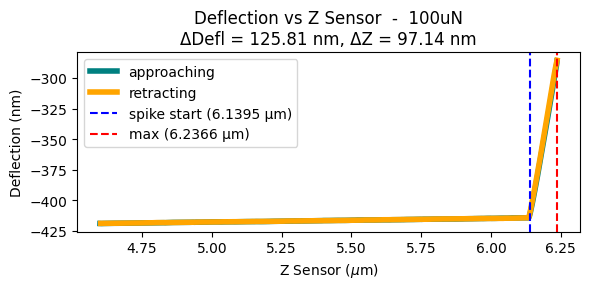

In [187]:
force_raw   = EXAMPLE_FILE.split('_')[2]
force_label = force_raw.replace('p', '.')

[idx_min], [idx_max] = get_curve_indices(example_path)

x_approach = df_example['ZSnsr'].iloc[:idx_max] * 1e6
y_approach = df_example['Defl'].iloc[:idx_max]  * 1e9
x_retract  = df_example['ZSnsr'].iloc[idx_max:] * 1e6
y_retract  = df_example['Defl'].iloc[idx_max:]  * 1e9

z_min = df_example['ZSnsr'].iloc[idx_min] * 1e6
z_max = df_example['ZSnsr'].iloc[idx_max] * 1e6

delta_defl = (df_example['Defl'].iloc[idx_max] - df_example['Defl'].iloc[idx_min]) * 1e9
delta_z    = (df_example['ZSnsr'].iloc[idx_max] - df_example['ZSnsr'].iloc[idx_min]) * 1e9

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x_approach, y_approach, color='teal',   linewidth=4)
ax.plot(x_retract,  y_retract,  color='orange', linewidth=4)
ax.axvline(z_min, color='blue', linestyle='--', linewidth=1.5, label=f'spike start ({z_min:.4f} µm)')
ax.axvline(z_max, color='red',  linestyle='--', linewidth=1.5, label=f'max ({z_max:.4f} µm)')

ax.legend(handles=[
    plt.Line2D([0], [0], color='teal',   linewidth=4,                  label='approaching'),
    plt.Line2D([0], [0], color='orange', linewidth=4,                  label='retracting'),
    plt.Line2D([0], [0], color='blue',   linestyle='--', linewidth=1.5, label=f'spike start ({z_min:.4f} µm)'),
    plt.Line2D([0], [0], color='red',    linestyle='--', linewidth=1.5, label=f'max ({z_max:.4f} µm)'),
])
ax.set_xlabel(r'Z Sensor ($\mu$m)')
ax.set_ylabel(r'Deflection (nm)')
ax.set_title(f'Deflection vs Z Sensor  -  {force_label}\nΔDefl = {delta_defl:.2f} nm, ΔZ = {delta_z:.2f} nm')
plt.tight_layout()

In [188]:
force_raw   = EXAMPLE_FILE.split('_')[2]
force_label = force_raw.replace('p', '.')

[idx_min], [idx_max] = get_curve_indices(example_path)

x_approach = df_example['ZSnsr'].iloc[:idx_max] * 1e6
y_approach = df_example['Defl'].iloc[:idx_max]  * 1e9
x_retract  = df_example['ZSnsr'].iloc[idx_max:] * 1e6
y_retract  = df_example['Defl'].iloc[idx_max:]  * 1e9

z_min = df_example['ZSnsr'].iloc[idx_min] * 1e6
z_max = df_example['ZSnsr'].iloc[idx_max] * 1e6

delta_defl = (df_example['Defl'].iloc[idx_max] - df_example['Defl'].iloc[idx_min]) * 1e9
delta_z    = (df_example['ZSnsr'].iloc[idx_max] - df_example['ZSnsr'].iloc[idx_min]) * 1e9

fig = go.Figure()

fig.add_trace(go.Scatter(x=x_approach, y=y_approach, mode='lines', name='approaching',
                         line=dict(color='orange', width=8)))
fig.add_trace(go.Scatter(x=x_retract, y=y_retract, mode='lines', name='retracting',
                         line=dict(color='teal', width=8)))

y_range = [min(y_approach.min(), y_retract.min()), max(y_approach.max(), y_retract.max())]
fig.add_trace(go.Scatter(x=[z_min, z_min], y=y_range, mode='lines', name=f'spike start ({z_min:.4f} µm)',
                         line=dict(color='blue', width=1.5, dash='dash')))
fig.add_trace(go.Scatter(x=[z_max, z_max], y=y_range, mode='lines', name=f'max ({z_max:.4f} µm)',
                         line=dict(color='red', width=1.5, dash='dash')))

fig.update_layout(
    title=f'Deflection vs Z Sensor  -  {force_label}<br><sup>ΔDefl = {delta_defl:.2f} nm  |  ΔZ = {delta_z:.2f} nm</sup>',
    xaxis=dict(title='Z Sensor (µm)'),
    yaxis=dict(title='Deflection (nm)'),
)
print(z_min, z_max)
fig.show()

6.139481 6.2366242


## Step 4 – Build results DataFrame

In [211]:
config.keys() 

dict_keys(['run_FD', 'run_FD2', 'run_FD3', 'run_FD4', 'run_FD5', 'run_FD6'])

In [236]:
rows = []
#runs_of_interest = config.keys()  # all runs
#runs_of_interest = ['run_FD4', 'run_FD5', 'run_FD6']
runs_of_interest = ['run_FD7']
for run in runs_of_interest:
    for force in config[run]['acquisitions']['Force']:
        result = get_average_indices(run, force)
        if result is None:
            continue
        rows.append({
            'run':        run,
            'force':      parse_force_to_N(force),
            'delta_defl': result['delta_defl'],
            'delta_z':    result['delta_z'],
        })

df_results = pd.DataFrame(rows)
df_results

,run,force,delta_defl,delta_z
0,run_FD7,0.0001,6.541427e-08,5.317816e-08
1,run_FD7,0.0002,1.367953e-07,1.051590e-07
2,run_FD7,0.0003,2.084606e-07,1.574181e-07
3,run_FD7,0.0004,2.805980e-07,2.085017e-07
4,run_FD7,0.0005,3.521065e-07,2.577794e-07
5,run_FD7,0.0006,4.236798e-07,3.058117e-07


In [ ]:
#df_results_FD17 = df_results.copy()

## Step 5 – Plot ΔDefl vs. ΔZ

In [237]:
run_to_plot = 'run_FD7'
df_plot = df_results[df_results['run'] == run_to_plot].sort_values('force')

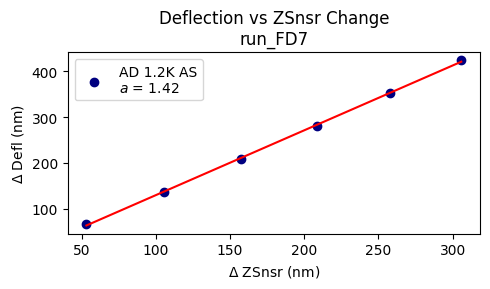

In [238]:

x5 = df_plot['delta_z'].to_numpy()    * 1e9
y5 = df_plot['delta_defl'].to_numpy() * 1e9
mask = ~(np.isnan(x5) | np.isnan(y5))
x5_clean = x5[mask]
y5_clean = y5[mask]

slope5, intercept5, r5, *_ = linregress(x5_clean, y5_clean)



fig, ax = plt.subplots(figsize=(5,3))


ax.scatter(x5, y5, color='navy', label=f'AD 1.2K AS\n$a$ = {slope5:.2f}')
ax.plot(x5, slope5 * x5 + intercept5, color='red')

ax.legend()
ax.set_xlabel(r'$\Delta$ ZSnsr (nm)')
ax.set_ylabel(r'$\Delta$ Defl (nm)')
ax.set_title(f'Deflection vs ZSnsr Change\n{run_to_plot}')
plt.tight_layout()
plt.show()

In [205]:


x5 = df_plot['delta_z'].to_numpy()    * 1e9
y5 = df_plot['delta_defl'].to_numpy() * 1e9
y6 = df_plot['force'].to_numpy()      * 1e6

mask = ~(np.isnan(x5) | np.isnan(y5))

slope5, intercept5, r5, *_ = linregress(y5[mask], x5[mask])
slope6, intercept6, r6, *_ = linregress(y5[mask], y6[mask])
k = slope6 * 1e-6 / 1e-9

fig = go.Figure()

fig.add_trace(go.Scatter(x=y5, y=x5, mode='markers', name='ΔZSnsr',
                         marker=dict(color='blue', size=5), yaxis='y1'))
fig.add_trace(go.Scatter(x=y5[mask], y=slope5 * y5[mask] + intercept5, mode='lines',
                         name=f'a = {slope5:.2f}, R² = {r5**2:.2f}',
                         line=dict(color='blue', dash='dash'), yaxis='y1'))

fig.add_trace(go.Scatter(x=y5, y=y6, mode='markers', name='Force',
                         marker=dict(color='red', size=5), yaxis='y2'))
fig.add_trace(go.Scatter(x=y5[mask], y=slope6 * y5[mask] + intercept6, mode='lines',
                         name=f'k_fit = {k:.2f} N/m, R² = {r6**2:.2f}',
                         line=dict(color='red', dash='dash'), yaxis='y2'))

fig.update_layout(
    title='ΔDefl vs ΔZSnsr and Force',
    xaxis=dict(title='Δ Defl (nm)'),
    yaxis=dict(title=dict(text='Δ ZSnsr (nm)', font=dict(color='blue')), tickfont=dict(color='blue')),
    yaxis2=dict(title=dict(text='Force (µN)', font=dict(color='red')), tickfont=dict(color='red'),
                overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99)
)

fig.show()

<class 'numpy.ndarray'>
[  19.470007   19.840628   20.107563         nan   20.83425    21.0689
         nan   21.859705   22.152107   22.251242   22.78648    23.711437
         nan   27.89966    30.514912   33.508514   31.45442    32.744537
   35.857285   39.060978   41.242855   44.271927   47.22915    49.9399
   52.70522    56.105366   58.899788   61.74514    64.07572    66.90425
   69.98607    73.50354    79.5244     85.68804    91.41968    97.535576
  105.76286   120.12515   133.86897   147.84291   163.23247   178.7389
  194.56456   236.65962   255.43796   271.64514   288.54675   309.2182
  327.85284   370.42764   409.31992   442.98712   488.9007    521.61383
  499.5668    500.31848   517.64935   550.0115    576.5805    606.7371
  615.3846    639.8077    674.529     704.2772    734.4024    770.6485
  803.9988    837.058     869.29913   902.8472    933.11017   953.2214
  965.84424   986.92633   998.57104  1024.2975   1049.8307   1078.0682
 1114.3761   1141.9178   1174.5742   1207.648

## Step 6 – Fit Force vs. ΔDefl → spring constant *k*

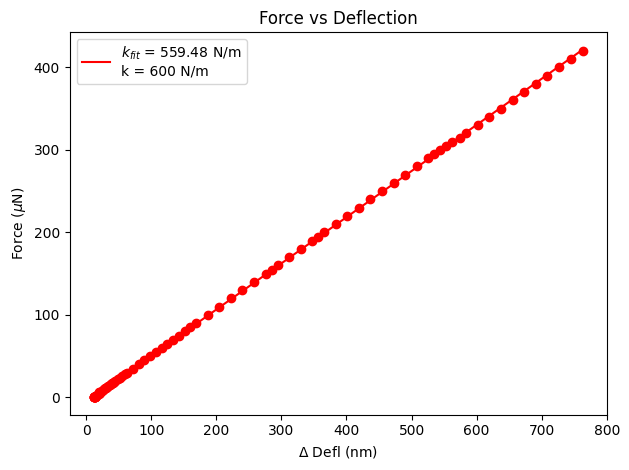

Spring constant k = 559.48 N/m


In [103]:
x6 = df_results['delta_defl'] * 1e9   # -> nm
y6 = df_results['force']      * 1e6   # -> uN

slope6, intercept6, r6, *_ = linregress(x6, y6)
k = slope6 * 1e-6 / 1e-9              # uN/nm -> N/m

# Pull spec k values from config for each run
spec_labels = f'k = {config[EXAMPLE_RUN]["spring_constant"]}'

fig, ax = plt.subplots()
ax.scatter(x6, y6, color='red')
ax.plot(x6, slope6 * x6 + intercept6, color='red',
        label=f'$k_{{fit}}$ = {k:.2f} N/m\n{spec_labels}')
ax.set_xlabel(r'$\Delta$ Defl (nm)')
ax.set_ylabel(r'Force ($\mu$N)')
ax.set_title('Force vs Deflection')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Spring constant k = {k:.2f} N/m')